# ADLS vs MPI - Count & Metadata Validation Framework

**Purpose:** Production-ready validation of record counts and metadata between ADLS (Databricks/Unity Catalog) and MPI (SQL Server) systems.

**Schemas Validated:**
| ADLS Schema | MPI Database | MPI Schema |
|---|---|---|
| `dw_btl_xli_ods_oz` | `ods3` | `dbo` |
| `dw_btl_xli_eds_oz` | `eds` | `dbo` |

**Outputs:**
- CSV: ADLS counts per schema
- CSV: MPI counts per schema  
- CSV: Count comparison report
- Excel: Final report with graphs and validation summary

In [0]:
# ============================================================
# Imports & Configuration
# ============================================================
import os
import datetime
from pyspark.sql.functions import (
    lit, col, lower, trim, when, broadcast, expr, count as spark_count
)
from pyspark.sql.types import StructType, StructField, StringType, LongType
import pandas as pd

# --- Run timestamp for file naming ---
run_timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
print(f"Validation run started at: {run_timestamp}")

# --- ADLS / Unity Catalog Configuration ---
BTL_CATALOG = "axiom_btl_prd_spl"

# --- Schema Mapping: ADLS schema → (MPI database, MPI schema) ---
SCHEMA_MAPPING = {
    "dw_btl_xli_ods_oz": {"mpi_database": "ods3", "mpi_schema": "dbo"},
    "dw_btl_xli_eds_oz": {"mpi_database": "eds",  "mpi_schema": "dbo"},
}

# --- Output directory (workspace) ---
OUTPUT_DIR = "/Workspace/Users/raja.annu@axaxl.com/WS4_validation/validation_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Output directory: {OUTPUT_DIR}")

# --- Data type mapping for metadata comparison ---
DATATYPE_MAPPING = {
    'int': 'int', 'smallint': 'int', 'bigint': 'int', 'tinyint': 'int',
    'varchar': 'string', 'char': 'string', 'nvarchar': 'string', 'nchar': 'string', 'text': 'string', 'ntext': 'string',
    'datetime': 'timestamp', 'datetime2': 'timestamp', 'smalldatetime': 'timestamp',
    'date': 'date',
    'timestamp': 'timestamp',
    'decimal': 'decimal', 'numeric': 'decimal', 'money': 'decimal', 'smallmoney': 'decimal',
    'float': 'double', 'real': 'float',
    'bit': 'boolean',
    'short': 'int', 'long': 'bigint',
}

Validation run started at: 20261005_114125


---------------------------------------------------------------------------
PermissionError                           Traceback (most recent call last)
File <command-6121663403537854>, line 27
     25 # --- Output directory (workspace) ---
     26 OUTPUT_DIR = "/Workspace/Users/raja.annu@axaxl.com/WS4_validation/validation_outputs"
---> 27 os.makedirs(OUTPUT_DIR, exist_ok=True)
     28 print(f"Output directory: {OUTPUT_DIR}")
     30 # --- Data type mapping for metadata comparison ---

File <frozen os>:215, in makedirs(name, mode, exist_ok)

File <frozen os>:215, in makedirs(name, mode, exist_ok)

File <frozen os>:225, in makedirs(name, mode, exist_ok)

PermissionError: [Errno 13] Permission denied: '/Workspace/Users/raja.annu@axaxl.com'

In [0]:
# ============================================================
# JDBC Connection to MPI SQL Server (Parameterized by database)
# ============================================================
def mpi_jdbc_query(sql_query, database_name):
    """
    Execute a SQL query against MPI SQL Server via JDBC.
    
    Args:
        sql_query (str): SQL query to execute.
        database_name (str): MPI database name (e.g., 'ods3', 'eds').
    
    Returns:
        pyspark.sql.DataFrame: Query results.
    """
    user = 'MS_DB_IDWS_PROD_MPI'
    password = dbutils.secrets.get(
        scope="zxlc0266xliiprue2key02",
        key="idwstageprdmpimssql"
    )
    jdbc_url = (
        f"jdbc:sqlserver://zpnxla1174.prprivmgmt.intraxa:30000;"
        f"database={database_name};"
        f"authentication=ActiveDirectoryServicePrincipal;"
        f"encrypt=true;trustServerCertificate=true"
    )
    driver_class = "com.microsoft.sqlserver.jdbc.SQLServerDriver"
    
    result_df = (
        spark.read
        .format("jdbc")
        .option("url", jdbc_url)
        .option("user", user)
        .option("password", password)
        .option("query", sql_query)
        .option("driver", driver_class)
        .load()
    )
    return result_df

print("MPI JDBC connection function ready.")

MPI JDBC connection function ready.


In [0]:
# ============================================================
# Discover all tables in each ADLS schema using information_schema
# ============================================================
adls_tables_by_schema = {}

for adls_schema, mpi_info in SCHEMA_MAPPING.items():
    tables_df = spark.sql(f"""
        SELECT DISTINCT lower(table_name) AS table_name
        FROM {BTL_CATALOG}.information_schema.tables
        WHERE table_schema = '{adls_schema}'
        ORDER BY table_name
    """)
    table_list = [row['table_name'] for row in tables_df.collect()]
    adls_tables_by_schema[adls_schema] = table_list
    print(f"Schema '{adls_schema}': Found {len(table_list)} tables")
    
print("\n--- Tables per Schema ---")
for schema, tables in adls_tables_by_schema.items():
    print(f"\n{schema} ({len(tables)} tables):")
    for t in tables:
        print(f"  - {t}")

---------------------------------------------------------------------------
AnalysisException                         Traceback (most recent call last)
File <command-6121663403537856>, line 7
      4 adls_tables_by_schema = {}
      6 for adls_schema, mpi_info in SCHEMA_MAPPING.items():
----> 7     tables_df = spark.sql(f"""
      8         SELECT DISTINCT lower(table_name) AS table_name
      9         FROM {BTL_CATALOG}.information_schema.tables
     10         WHERE table_schema = '{adls_schema}'
     11         ORDER BY table_name
     12     """)
     13     table_list = [row['table_name'] for row in tables_df.collect()]
     14     adls_tables_by_schema[adls_schema] = table_list

File /databricks/spark/python/pyspark/sql/connect/session.py:736, in SparkSession.sql(self, sqlQuery, args, **kwargs)
    733         _views.append(SubqueryAlias(df._plan, name))
    735 cmd = SQL(sqlQuery, _args, _named_args, _views)
--> 736 data, properties, ei = self.client.execute_command(cmd.command

In [0]:
# ============================================================
# Extract record counts from all ADLS tables
# ============================================================
from pyspark.sql.types import StructType, StructField, StringType, LongType

adls_count_schema = StructType([
    StructField("catalog", StringType(), True),
    StructField("adls_schema", StringType(), True),
    StructField("table_name", StringType(), True),
    StructField("adls_count", LongType(), True),
    StructField("adls_status", StringType(), True),
])

adls_count_records = []

for adls_schema, table_list in adls_tables_by_schema.items():
    print(f"\nCounting tables in ADLS schema: {adls_schema}")
    for table_name in table_list:
        full_table = f"{BTL_CATALOG}.{adls_schema}.{table_name}"
        try:
            cnt = spark.table(full_table).count()
            adls_count_records.append((BTL_CATALOG, adls_schema, table_name, cnt, "SUCCESS"))
            print(f"  {table_name}: {cnt:,} rows")
        except Exception as e:
            adls_count_records.append((BTL_CATALOG, adls_schema, table_name, -1, f"ERROR: {str(e)[:100]}"))
            print(f"  {table_name}: ERROR - {str(e)[:100]}")

adls_counts_df = spark.createDataFrame(adls_count_records, schema=adls_count_schema)
print(f"\nTotal ADLS tables processed: {adls_counts_df.count()}")
display(adls_counts_df.orderBy("adls_schema", "table_name"))


Counting tables in ADLS schema: dw_btl_xli_ods_oz
  accountmanagers: 695 rows
  accountrevenuelink: 248,289,392 rows
  accountsheader: 440,686 rows
  accountsheaderlink: 445,905 rows
  addresscodes: 6,839,122 rows
  addressheader: 7,541,656 rows
  aircraftdetails: 26,490 rows
  allocationhistory: 213,370,237 rows
  allocationhistory_inc: 213,370,237 rows
  allocationreportinghistory: 21,848,404 rows
  areacodes: 6,740 rows
  arg_transpolicyinwards_summary: 154,815 rows
  baseccycompany: 24 rows
  branchnames: 53 rows
  brokers: 67,807 rows
  cashallocations: 123,406,254 rows
  catastrophecodesinternal: 2,139 rows
  catastrophecodesmarket: 2,094 rows
  catastrophecodesswiss: 3,541 rows
  ceresbusiness: 40,959 rows
  ceresbusiness_temp: 39,721 rows
  ceresclient: 889,377 rows
  ceresemployee: 1,041 rows
  cerespartner: 889,377 rows
  circumstancecausecodes: 2,335 rows
  claimants: 2,380,090 rows
  claimclaimants: 6,660,232 rows
  claimheader: 5,145,733 rows
  claimhistory: 7,355,964 row

catalog,adls_schema,table_name,adls_count,adls_status
axiom_btl_prd_spl,dw_btl_xli_eds_oz,d_broker,81140,SUCCESS
axiom_btl_prd_spl,dw_btl_xli_eds_oz,d_claim,5145734,SUCCESS
axiom_btl_prd_spl,dw_btl_xli_eds_oz,d_claimhistory,7574450,SUCCESS
axiom_btl_prd_spl,dw_btl_xli_eds_oz,d_claimorgstructure,46,SUCCESS
axiom_btl_prd_spl,dw_btl_xli_eds_oz,d_claimtranstype,747,SUCCESS
axiom_btl_prd_spl,dw_btl_xli_eds_oz,d_client,7665763,SUCCESS
axiom_btl_prd_spl,dw_btl_xli_eds_oz,d_coinsurer,9776,SUCCESS
axiom_btl_prd_spl,dw_btl_xli_eds_oz,d_countryorgstructure,32,SUCCESS
axiom_btl_prd_spl,dw_btl_xli_eds_oz,d_coveragebandings,34,SUCCESS
axiom_btl_prd_spl,dw_btl_xli_eds_oz,d_coveragedeductibles,9612382,SUCCESS


In [0]:
# ============================================================
# Extract record counts from all MPI tables
# ============================================================
mpi_count_schema = StructType([
    StructField("mpi_database", StringType(), True),
    StructField("mpi_schema", StringType(), True),
    StructField("table_name", StringType(), True),
    StructField("mpi_count", LongType(), True),
    StructField("mpi_status", StringType(), True),
])

mpi_count_records = []

for adls_schema, mpi_info in SCHEMA_MAPPING.items():
    mpi_db = mpi_info["mpi_database"]
    mpi_schema = mpi_info["mpi_schema"]
    table_list = adls_tables_by_schema.get(adls_schema, [])
    
    print(f"\nCounting tables in MPI: database={mpi_db}, schema={mpi_schema}")
    
    # First, get list of tables that actually exist in MPI
    try:
        mpi_tables_query = f"""
            SELECT lower(table_name) AS table_name
            FROM {mpi_db}.information_schema.tables
            WHERE table_schema = '{mpi_schema}'
        """
        mpi_existing_tables_df = mpi_jdbc_query(mpi_tables_query, mpi_db)
        mpi_existing_tables = set(
            row['table_name'].lower() for row in mpi_existing_tables_df.collect()
        )
        print(f"  MPI has {len(mpi_existing_tables)} tables in {mpi_db}.{mpi_schema}")
    except Exception as e:
        print(f"  ERROR fetching MPI table list: {e}")
        mpi_existing_tables = set()
    
    for table_name in table_list:
        if table_name not in mpi_existing_tables:
            mpi_count_records.append((mpi_db, mpi_schema, table_name, -1, "TABLE_NOT_FOUND_IN_MPI"))
            print(f"  {table_name}: NOT FOUND in MPI")
            continue
        try:
            count_query = f"SELECT COUNT(*) AS cnt FROM {mpi_schema}.{table_name}"
            cnt_df = mpi_jdbc_query(count_query, mpi_db)
            cnt = cnt_df.collect()[0]['cnt']
            mpi_count_records.append((mpi_db, mpi_schema, table_name, cnt, "SUCCESS"))
            print(f"  {table_name}: {cnt:,} rows")
        except Exception as e:
            mpi_count_records.append((mpi_db, mpi_schema, table_name, -1, f"ERROR: {str(e)[:100]}"))
            print(f"  {table_name}: ERROR - {str(e)[:100]}")

mpi_counts_df = spark.createDataFrame(mpi_count_records, schema=mpi_count_schema)
print(f"\nTotal MPI tables processed: {mpi_counts_df.count()}")
display(mpi_counts_df.orderBy("mpi_database", "table_name"))


Counting tables in MPI: database=ods3, schema=dbo
  MPI has 334 tables in ods3.dbo
  accountmanagers: 695 rows
  accountrevenuelink: 248,289,392 rows
  accountsheader: 440,686 rows
  accountsheaderlink: 445,905 rows
  addresscodes: 6,839,122 rows
  addressheader: 7,541,656 rows
  aircraftdetails: 26,490 rows
  allocationhistory: 213,370,237 rows
  allocationhistory_inc: NOT FOUND in MPI
  allocationreportinghistory: 21,848,404 rows
  areacodes: 6,740 rows
  arg_transpolicyinwards_summary: 154,815 rows
  baseccycompany: 24 rows
  branchnames: 53 rows
  brokers: 67,807 rows
  cashallocations: 123,406,254 rows
  catastrophecodesinternal: 2,139 rows
  catastrophecodesmarket: 2,094 rows
  catastrophecodesswiss: 3,541 rows
  ceresbusiness: 40,959 rows
  ceresbusiness_temp: 39,721 rows
  ceresclient: 889,377 rows
  ceresemployee: 1,041 rows
  cerespartner: 889,377 rows
  circumstancecausecodes: 2,335 rows
  claimants: 2,380,090 rows
  claimclaimants: 6,660,232 rows
  claimheader: 5,145,733 r

mpi_database,mpi_schema,table_name,mpi_count,mpi_status
eds,dbo,d_broker,81140,SUCCESS
eds,dbo,d_claim,5145734,SUCCESS
eds,dbo,d_claimhistory,7574450,SUCCESS
eds,dbo,d_claimorgstructure,46,SUCCESS
eds,dbo,d_claimtranstype,747,SUCCESS
eds,dbo,d_client,7665763,SUCCESS
eds,dbo,d_coinsurer,9776,SUCCESS
eds,dbo,d_countryorgstructure,32,SUCCESS
eds,dbo,d_coveragebandings,34,SUCCESS
eds,dbo,d_coveragedeductibles,9612382,SUCCESS


In [0]:
# ============================================================
# Save ADLS and MPI counts to separate CSV files
# ============================================================

# Convert to pandas for CSV export
adls_counts_pd = adls_counts_df.orderBy("adls_schema", "table_name").toPandas()
mpi_counts_pd = mpi_counts_df.orderBy("mpi_database", "table_name").toPandas()

# File paths
adls_csv_path = os.path.join(OUTPUT_DIR, f"adls_counts_{run_timestamp}.csv")
mpi_csv_path = os.path.join(OUTPUT_DIR, f"mpi_counts_{run_timestamp}.csv")

adls_counts_pd.to_csv(adls_csv_path, index=False)
mpi_counts_pd.to_csv(mpi_csv_path, index=False)

print(f"ADLS counts saved to: {adls_csv_path}")
print(f"MPI counts saved to:  {mpi_csv_path}")
print(f"\nADLS CSV rows: {len(adls_counts_pd)}")
print(f"MPI CSV rows:  {len(mpi_counts_pd)}")

ADLS counts saved to: /Workspace/Users/manasvi.pipariya@axaxl.com/WS4_validation/validation_outputs/adls_counts_20260930_200812.csv
MPI counts saved to:  /Workspace/Users/manasvi.pipariya@axaxl.com/WS4_validation/validation_outputs/mpi_counts_20260930_200812.csv

ADLS CSV rows: 256
MPI CSV rows:  256


In [0]:
# ============================================================
# Count Comparison: ADLS vs MPI
# ============================================================

# Build the mapping from adls_schema to mpi_database for join
schema_to_mpi_db = {s: m["mpi_database"] for s, m in SCHEMA_MAPPING.items()}
schema_to_mpi_schema = {s: m["mpi_schema"] for s, m in SCHEMA_MAPPING.items()}

# Add mpi_database column to ADLS counts for proper join
from pyspark.sql.functions import udf
from pyspark.sql.types import StringType as ST

# Create mapping broadcast
mapping_expr_db = "CASE " + " ".join(
    [f"WHEN adls_schema = '{k}' THEN '{v}'" for k, v in schema_to_mpi_db.items()]
) + " ELSE NULL END"

adls_with_mpi_key = adls_counts_df.withColumn("join_mpi_db", expr(mapping_expr_db))

# Join ADLS and MPI counts
comparison_df = adls_with_mpi_key.alias("a").join(
    mpi_counts_df.alias("m"),
    (col("a.table_name") == col("m.table_name")) &
    (col("a.join_mpi_db") == col("m.mpi_database")),
    how="full_outer"
).select(
    col("a.adls_schema"),
    col("a.table_name").alias("adls_table_name"),
    col("a.adls_count"),
    col("a.adls_status"),
    col("m.mpi_database"),
    col("m.mpi_schema"),
    col("m.table_name").alias("mpi_table_name"),
    col("m.mpi_count"),
    col("m.mpi_status"),
)

# Calculate difference and match status
comparison_df = comparison_df.withColumn(
    "count_difference", col("adls_count") - col("mpi_count")
).withColumn(
    "match_status",
    when(col("adls_status") != "SUCCESS", "ADLS_ERROR")
    .when(col("mpi_status") != "SUCCESS", "MPI_ERROR")
    .when(col("adls_count") == col("mpi_count"), "MATCHED")
    .when(col("count_difference") != 0, "MISMATCHED")
    .otherwise("UNKNOWN")
).withColumn(
    "abs_difference", when(col("count_difference").isNotNull(), 
                          expr("ABS(count_difference)")).otherwise(lit(None))
).withColumn(
    "pct_difference",
    when(
        (col("mpi_count") > 0) & (col("adls_count").isNotNull()),
        expr("ROUND(ABS(adls_count - mpi_count) * 100.0 / mpi_count, 2)")
    ).otherwise(lit(None))
)

comparison_df = comparison_df.orderBy("adls_schema", "adls_table_name")

# --- Separate out tables not found in MPI (ADLS-only) ---
not_found_in_mpi = comparison_df.filter(col("mpi_status") == "TABLE_NOT_FOUND_IN_MPI")
not_found_count = not_found_in_mpi.count()

# Remove TABLE_NOT_FOUND_IN_MPI from the comparison report
comparison_df = comparison_df.filter(col("mpi_status") != "TABLE_NOT_FOUND_IN_MPI")

print("=" * 80)
print("COUNT COMPARISON SUMMARY")
print("=" * 80)

total_tables = comparison_df.count()
matched = comparison_df.filter(col("match_status") == "MATCHED").count()
mismatched = comparison_df.filter(col("match_status") == "MISMATCHED").count()
errors = comparison_df.filter(col("match_status").isin("ADLS_ERROR", "MPI_ERROR", "UNKNOWN")).count()

print(f"Total Tables Compared : {total_tables}")
print(f"Matched               : {matched}")
print(f"Mismatched            : {mismatched}")
print(f"Errors                : {errors}")
print(f"Match Rate            : {matched/total_tables*100:.1f}%" if total_tables > 0 else "N/A")
print(f"\nExcluded (ADLS-only, not in MPI): {not_found_count}")

if not_found_count > 0:
    print("\n--- Excluded: Tables in ADLS but NOT in MPI ---")
    display(not_found_in_mpi.select("adls_schema", "adls_table_name"))

print("\n--- MISMATCHED Tables ---")
display(comparison_df.filter(col("match_status") == "MISMATCHED"))

print("\n--- ALL Tables ---")
display(comparison_df)

COUNT COMPARISON SUMMARY
Total Tables Compared : 246
Matched               : 240
Mismatched            : 5
Errors                : 1
Match Rate            : 97.6%

Excluded (ADLS-only, not in MPI): 10

--- Excluded: Tables in ADLS but NOT in MPI ---


adls_schema,adls_table_name
dw_btl_xli_eds_oz,lk_narratives
dw_btl_xli_eds_oz,lk_policysectiondetail
dw_btl_xli_eds_oz,lk_ribordereau
dw_btl_xli_ods_oz,allocationhistory_inc
dw_btl_xli_ods_oz,corpclaimpayments
dw_btl_xli_ods_oz,corpreservedeltaoutwards
dw_btl_xli_ods_oz,corpreservedeltas
dw_btl_xli_ods_oz,inwardscoinsurancegroup
dw_btl_xli_ods_oz,lm45
dw_btl_xli_ods_oz,lm45_claim_policy_inwards_outwards



--- MISMATCHED Tables ---


adls_schema,adls_table_name,adls_count,adls_status,mpi_database,mpi_schema,mpi_table_name,mpi_count,mpi_status,count_difference,match_status,abs_difference,pct_difference
dw_btl_xli_eds_oz,d_narratives,2612663,SUCCESS,eds,dbo,d_narratives,2612662,SUCCESS,1,MISMATCHED,1,0.00
dw_btl_xli_eds_oz,f_cratransoutwards,495464434,SUCCESS,eds,dbo,f_cratransoutwards,495464437,SUCCESS,-3,MISMATCHED,3,0.00
dw_btl_xli_eds_oz,f_sep_pipeline_allocs_psoft,17182104,SUCCESS,eds,dbo,f_sep_pipeline_allocs_psoft,17182103,SUCCESS,1,MISMATCHED,1,0.00
dw_btl_xli_ods_oz,narratives,43138229,SUCCESS,ods3,dbo,narratives,43138220,SUCCESS,9,MISMATCHED,9,0.00
dw_btl_xli_ods_oz,ukmisabfdetail,185258,SUCCESS,ods3,dbo,ukmisabfdetail,185222,SUCCESS,36,MISMATCHED,36,0.02



--- ALL Tables ---


adls_schema,adls_table_name,adls_count,adls_status,mpi_database,mpi_schema,mpi_table_name,mpi_count,mpi_status,count_difference,match_status,abs_difference,pct_difference
dw_btl_xli_eds_oz,d_broker,81140,SUCCESS,eds,dbo,d_broker,81140,SUCCESS,0,MATCHED,0,0.00
dw_btl_xli_eds_oz,d_claim,5145734,SUCCESS,eds,dbo,d_claim,5145734,SUCCESS,0,MATCHED,0,0.00
dw_btl_xli_eds_oz,d_claimhistory,7574450,SUCCESS,eds,dbo,d_claimhistory,7574450,SUCCESS,0,MATCHED,0,0.00
dw_btl_xli_eds_oz,d_claimorgstructure,46,SUCCESS,eds,dbo,d_claimorgstructure,46,SUCCESS,0,MATCHED,0,0.00
dw_btl_xli_eds_oz,d_claimtranstype,747,SUCCESS,eds,dbo,d_claimtranstype,747,SUCCESS,0,MATCHED,0,0.00
dw_btl_xli_eds_oz,d_client,7665763,SUCCESS,eds,dbo,d_client,7665763,SUCCESS,0,MATCHED,0,0.00
dw_btl_xli_eds_oz,d_coinsurer,9776,SUCCESS,eds,dbo,d_coinsurer,9776,SUCCESS,0,MATCHED,0,0.00
dw_btl_xli_eds_oz,d_countryorgstructure,32,SUCCESS,eds,dbo,d_countryorgstructure,32,SUCCESS,0,MATCHED,0,0.00
dw_btl_xli_eds_oz,d_coveragebandings,34,SUCCESS,eds,dbo,d_coveragebandings,34,SUCCESS,0,MATCHED,0,0.00
dw_btl_xli_eds_oz,d_coveragedeductibles,9612382,SUCCESS,eds,dbo,d_coveragedeductibles,9612382,SUCCESS,0,MATCHED,0,0.00


In [0]:
# ============================================================
# Save count comparison report to CSV
# ============================================================
comparison_pd = comparison_df.toPandas()
comparison_csv_path = os.path.join(OUTPUT_DIR, f"count_comparison_{run_timestamp}.csv")
comparison_pd.to_csv(comparison_csv_path, index=False)
print(f"Count comparison saved to: {comparison_csv_path}")
print(f"Rows: {len(comparison_pd)}")

Count comparison saved to: /Workspace/Users/manasvi.pipariya@axaxl.com/WS4_validation/validation_outputs/count_comparison_20260930_200812.csv
Rows: 246


## Metadata Validation
Compare column-level metadata (column names, data types, precision, scale) between ADLS and MPI for all tables.

In [0]:
# ============================================================
# Metadata Validation: Column-level comparison ADLS vs MPI
# ============================================================
from pyspark.sql.functions import lower, col, expr, lit, when

# Build the mapping expression for data type normalization
mapping_case_expr = "CASE " + " ".join(
    [f"WHEN lower(data_type) = '{k}' THEN '{v}'" for k, v in DATATYPE_MAPPING.items()]
) + " ELSE lower(data_type) END"

all_metadata_results = []

for adls_schema, mpi_info in SCHEMA_MAPPING.items():
    mpi_db = mpi_info["mpi_database"]
    mpi_schema = mpi_info["mpi_schema"]
    
    print(f"\n{'='*60}")
    print(f"Metadata validation: {adls_schema} vs {mpi_db}.{mpi_schema}")
    print(f"{'='*60}")
    
    # --- ADLS metadata ---
    adls_meta_df = spark.sql(f"""
        SELECT 
            table_schema AS schema_name,
            lower(table_name) AS table_name,
            lower(column_name) AS column_name,
            lower(data_type) AS data_type,
            numeric_precision,
            numeric_scale,
            ordinal_position
        FROM {BTL_CATALOG}.information_schema.columns
        WHERE table_schema = '{adls_schema}'
        ORDER BY table_name, ordinal_position
    """)
    adls_meta_df = adls_meta_df.withColumn("normalized_type", expr(mapping_case_expr))
    
    # --- MPI metadata ---
    mpi_meta_query = f"""
        SELECT 
            table_schema AS schema_name,
            lower(table_name) AS table_name,
            lower(column_name) AS column_name,
            lower(data_type) AS data_type,
            numeric_precision,
            numeric_scale,
            ordinal_position
        FROM {mpi_db}.information_schema.columns
        WHERE table_schema = '{mpi_schema}'
    """
    try:
        mpi_meta_df = mpi_jdbc_query(mpi_meta_query, mpi_db)
        # Filter MPI to only tables that exist in ADLS
        adls_table_list = adls_tables_by_schema.get(adls_schema, [])
        mpi_meta_df = mpi_meta_df.filter(
            lower(col("table_name")).isin(adls_table_list)
        )
        mpi_meta_df = mpi_meta_df.withColumn("normalized_type", expr(mapping_case_expr))
    except Exception as e:
        print(f"  ERROR fetching MPI metadata: {e}")
        continue
    
    # --- Extra columns in ADLS (not in MPI) ---
    extra_in_adls = adls_meta_df.alias("a").join(
        mpi_meta_df.alias("m"),
        (lower(col("a.table_name")) == lower(col("m.table_name"))) &
        (lower(col("a.column_name")) == lower(col("m.column_name"))),
        how="left_anti"
    ).withColumn("issue", lit("EXTRA_IN_ADLS")).withColumn("adls_schema_name", lit(adls_schema))
    
    # --- Extra columns in MPI (not in ADLS) ---
    extra_in_mpi = mpi_meta_df.alias("m").join(
        adls_meta_df.alias("a"),
        (lower(col("m.table_name")) == lower(col("a.table_name"))) &
        (lower(col("m.column_name")) == lower(col("a.column_name"))),
        how="left_anti"
    ).withColumn("issue", lit("EXTRA_IN_MPI")).withColumn("adls_schema_name", lit(adls_schema))
    
    # --- Data type mismatches ---
    joined_meta = adls_meta_df.alias("a").join(
        mpi_meta_df.alias("m"),
        (lower(col("a.table_name")) == lower(col("m.table_name"))) &
        (lower(col("a.column_name")) == lower(col("m.column_name"))),
        how="inner"
    )
    
    datatype_mismatches = joined_meta.filter(
        (col("a.normalized_type") != col("m.normalized_type")) |
        (
            col("a.normalized_type").isin("decimal") &
            col("a.numeric_precision").isNotNull() &
            col("m.numeric_precision").isNotNull() &
            (col("a.numeric_precision") != col("m.numeric_precision"))
        ) |
        (
            col("a.normalized_type").isin("decimal") &
            col("a.numeric_scale").isNotNull() &
            col("m.numeric_scale").isNotNull() &
            (col("a.numeric_scale") != col("m.numeric_scale"))
        )
    ).select(
        lit(adls_schema).alias("adls_schema_name"),
        col("a.table_name"),
        col("a.column_name"),
        col("a.data_type").alias("adls_raw_type"),
        col("a.normalized_type").alias("adls_normalized_type"),
        col("m.data_type").alias("mpi_raw_type"),
        col("m.normalized_type").alias("mpi_normalized_type"),
        col("a.numeric_precision").alias("adls_precision"),
        col("m.numeric_precision").alias("mpi_precision"),
        col("a.numeric_scale").alias("adls_scale"),
        col("m.numeric_scale").alias("mpi_scale"),
    ).withColumn("issue", lit("DATATYPE_MISMATCH"))
    
    extra_adls_cnt = extra_in_adls.count()
    extra_mpi_cnt = extra_in_mpi.count()
    dtype_mismatch_cnt = datatype_mismatches.count()
    
    print(f"  Extra columns in ADLS only : {extra_adls_cnt}")
    print(f"  Extra columns in MPI only  : {extra_mpi_cnt}")
    print(f"  Data type mismatches       : {dtype_mismatch_cnt}")
    
    if extra_adls_cnt > 0:
        print("\n  --- Extra in ADLS ---")
        display(extra_in_adls.select("adls_schema_name", "table_name", "column_name", "data_type", "issue"))
    if extra_mpi_cnt > 0:
        print("\n  --- Extra in MPI ---")
        display(extra_in_mpi.select("adls_schema_name", "table_name", "column_name", "data_type", "issue"))
    if dtype_mismatch_cnt > 0:
        print("\n  --- Data Type Mismatches ---")
        display(datatype_mismatches)
    
    all_metadata_results.append({
        "adls_schema": adls_schema,
        "mpi_database": mpi_db,
        "extra_in_adls": extra_adls_cnt,
        "extra_in_mpi": extra_mpi_cnt,
        "datatype_mismatches": dtype_mismatch_cnt,
    })

print("\n" + "="*60)
print("METADATA VALIDATION SUMMARY")
print("="*60)
for r in all_metadata_results:
    print(f"  {r['adls_schema']} vs {r['mpi_database']}: "
          f"Extra ADLS={r['extra_in_adls']}, Extra MPI={r['extra_in_mpi']}, "
          f"Type Mismatches={r['datatype_mismatches']}")


Metadata validation: dw_btl_xli_ods_oz vs ods3.dbo
  Extra columns in ADLS only : 330
  Extra columns in MPI only  : 3
  Data type mismatches       : 21

  --- Extra in ADLS ---


adls_schema_name,table_name,column_name,data_type,issue
dw_btl_xli_ods_oz,allocationhistory_inc,curropenamtbase,double,EXTRA_IN_ADLS
dw_btl_xli_ods_oz,accountsheaderlink,dw_insert_dt,timestamp,EXTRA_IN_ADLS
dw_btl_xli_ods_oz,allocationhistory_inc,acctmasterseq,decimal,EXTRA_IN_ADLS
dw_btl_xli_ods_oz,allocationhistory_inc,origbasepaidoprd,string,EXTRA_IN_ADLS
dw_btl_xli_ods_oz,allocationhistory_inc,fkcompanynamecode,string,EXTRA_IN_ADLS
dw_btl_xli_ods_oz,areacodes,dw_insert_dt,timestamp,EXTRA_IN_ADLS
dw_btl_xli_ods_oz,allocationhistory_inc,allocamtorig,double,EXTRA_IN_ADLS
dw_btl_xli_ods_oz,allocationhistory_inc,allocationreversible,string,EXTRA_IN_ADLS
dw_btl_xli_ods_oz,areacodes,term,string,EXTRA_IN_ADLS
dw_btl_xli_ods_oz,baseccycompany,terminator,string,EXTRA_IN_ADLS



  --- Extra in MPI ---


adls_schema_name,table_name,column_name,data_type,issue
dw_btl_xli_ods_oz,promptexposure,exposurecode,char,EXTRA_IN_MPI
dw_btl_xli_ods_oz,xrefidwbusunit,busunitdesc,char,EXTRA_IN_MPI
dw_btl_xli_ods_oz,xrefidwbusunit,busunitcd,char,EXTRA_IN_MPI



  --- Data Type Mismatches ---


...


  --- Extra in MPI ---


adls_schema_name,table_name,column_name,data_type,issue
dw_btl_xli_eds_oz,d_quote,pamcode,varchar,EXTRA_IN_MPI
dw_btl_xli_eds_oz,d_quote,pamname,varchar,EXTRA_IN_MPI
dw_btl_xli_eds_oz,d_quote,damcode,varchar,EXTRA_IN_MPI
dw_btl_xli_eds_oz,d_quote,damname,varchar,EXTRA_IN_MPI
dw_btl_xli_eds_oz,d_quote,acocode,varchar,EXTRA_IN_MPI
dw_btl_xli_eds_oz,d_quote,aconame,varchar,EXTRA_IN_MPI



  --- Data Type Mismatches ---


adls_schema_name,table_name,column_name,adls_raw_type,adls_normalized_type,mpi_raw_type,mpi_normalized_type,adls_precision,mpi_precision,adls_scale,mpi_scale,issue
dw_btl_xli_eds_oz,d_claimhistory,daysthisversion,long,bigint,numeric,decimal,null,6,null,0,DATATYPE_MISMATCH
dw_btl_xli_eds_oz,d_ribordereau,stats,int,int,numeric,decimal,null,10,null,0,DATATYPE_MISMATCH
dw_btl_xli_eds_oz,d_ribordereau,statsposting,int,int,numeric,decimal,null,4,null,0,DATATYPE_MISMATCH
dw_btl_xli_eds_oz,f_policyinwards,fkreportingperiod,decimal,decimal,numeric,decimal,10,7,0,0,DATATYPE_MISMATCH
dw_btl_xli_eds_oz,f_policyoutwards,fkreportingperiod,decimal,decimal,numeric,decimal,10,7,0,0,DATATYPE_MISMATCH
dw_btl_xli_eds_oz,f_allocationhistory,fkacctingperiod,double,double,char,string,null,null,null,null,DATATYPE_MISMATCH
dw_btl_xli_eds_oz,f_generalledger,fkacctingperiod,decimal,decimal,char,string,10,null,0,null,DATATYPE_MISMATCH
dw_btl_xli_eds_oz,f_generalledger,statspostingseq,int,int,numeric,decimal,null,4,null,0,DATATYPE_MISMATCH
dw_btl_xli_eds_oz,f_generalledger,statsheaderseq,int,int,numeric,decimal,null,10,null,0,DATATYPE_MISMATCH
dw_btl_xli_eds_oz,f_claimoutwards,fkfinancialtime,decimal,decimal,decimal,decimal,10,6,0,0,DATATYPE_MISMATCH



METADATA VALIDATION SUMMARY
  dw_btl_xli_ods_oz vs ods3: Extra ADLS=330, Extra MPI=3, Type Mismatches=21
  dw_btl_xli_eds_oz vs eds: Extra ADLS=18, Extra MPI=6, Type Mismatches=93


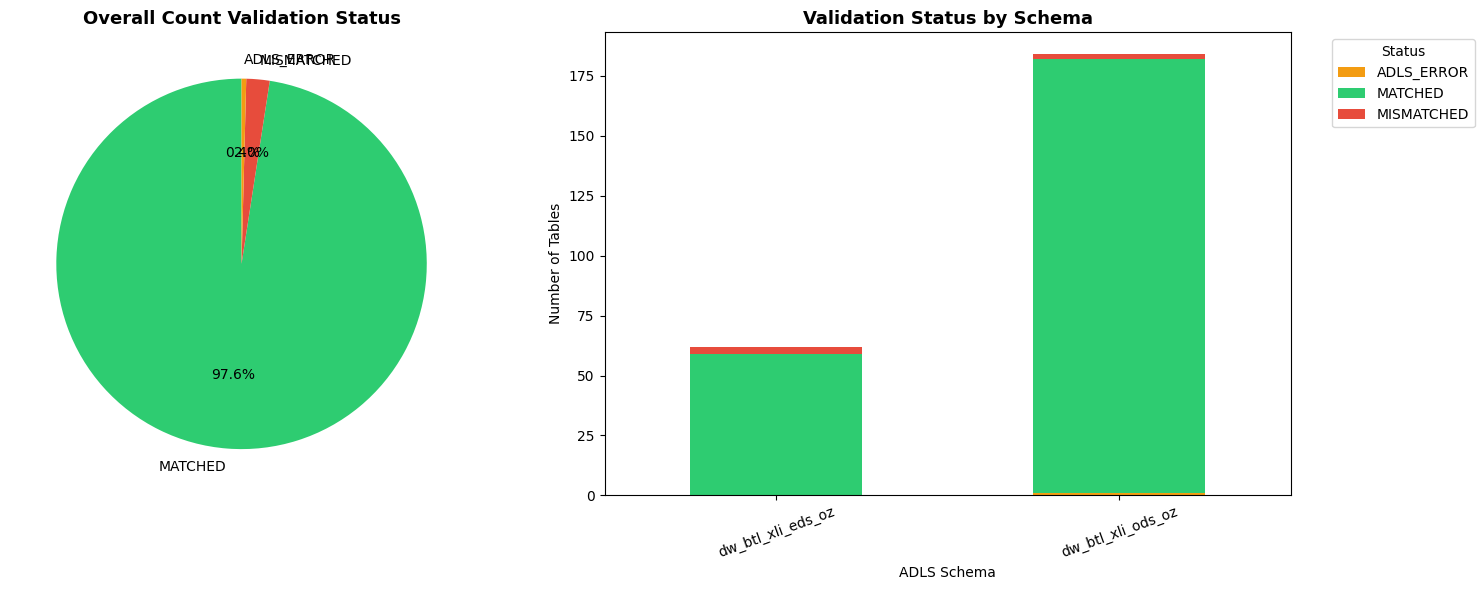

Chart saved: /Workspace/Users/manasvi.pipariya@axaxl.com/WS4_validation/validation_outputs/chart_count_status_20260930_200812.png


In [0]:
# ============================================================
# Visualization: Count Comparison Charts
# ============================================================
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np

comp_pd = comparison_df.toPandas()

# --- Chart 1: Match Status Pie Chart (Overall) ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

status_counts = comp_pd['match_status'].value_counts()
colors_map = {'MATCHED': '#2ecc71', 'MISMATCHED': '#e74c3c', 'ADLS_ERROR': '#f39c12', 'MPI_ERROR': '#e67e22', 'UNKNOWN': '#95a5a6'}
colors = [colors_map.get(s, '#95a5a6') for s in status_counts.index]

axes[0].pie(status_counts.values, labels=status_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, textprops={'fontsize': 10})
axes[0].set_title('Overall Count Validation Status', fontsize=13, fontweight='bold')

# --- Chart 2: Match Status by Schema (Stacked Bar) ---
schema_status = comp_pd.groupby(['adls_schema', 'match_status']).size().unstack(fill_value=0)
schema_status.plot(kind='bar', stacked=True, ax=axes[1],
                   color=[colors_map.get(c, '#95a5a6') for c in schema_status.columns])
axes[1].set_title('Validation Status by Schema', fontsize=13, fontweight='bold')
axes[1].set_xlabel('ADLS Schema')
axes[1].set_ylabel('Number of Tables')
axes[1].legend(title='Status', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
chart1_path = os.path.join(OUTPUT_DIR, f"chart_count_status_{run_timestamp}.png")
plt.savefig(chart1_path, dpi=150, bbox_inches='tight')
display(plt.gcf())
plt.close()
print(f"Chart saved: {chart1_path}")

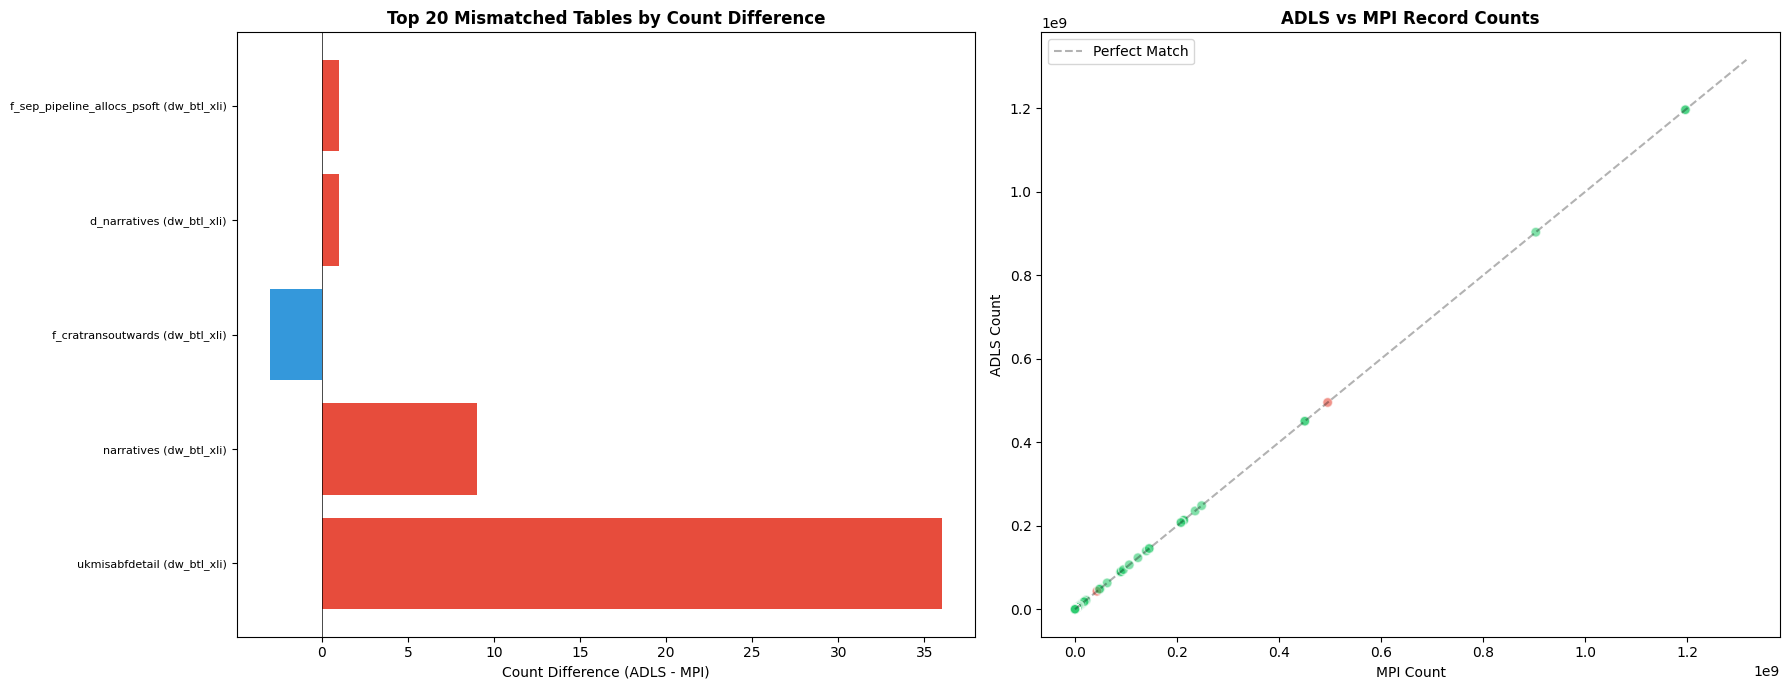

Chart saved: /Workspace/Users/manasvi.pipariya@axaxl.com/WS4_validation/validation_outputs/chart_mismatch_detail_20260930_200812.png


In [0]:
# ============================================================
# Visualization: Top Mismatched Tables & Count Distribution
# ============================================================
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np

comp_pd = comparison_df.toPandas()
mismatched_pd = comp_pd[comp_pd['match_status'] == 'MISMATCHED'].copy()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Chart 3: Top 20 mismatched tables by absolute difference ---
if len(mismatched_pd) > 0:
    mismatched_pd['abs_diff'] = mismatched_pd['count_difference'].abs()
    top_mismatched = mismatched_pd.nlargest(20, 'abs_diff')
    
    y_pos = np.arange(len(top_mismatched))
    bar_colors = ['#e74c3c' if d > 0 else '#3498db' for d in top_mismatched['count_difference']]
    
    axes[0].barh(y_pos, top_mismatched['count_difference'], color=bar_colors)
    axes[0].set_yticks(y_pos)
    axes[0].set_yticklabels(
        [f"{row['adls_table_name']} ({row['adls_schema'][:10]})" 
         for _, row in top_mismatched.iterrows()], fontsize=8
    )
    axes[0].set_xlabel('Count Difference (ADLS - MPI)')
    axes[0].set_title('Top 20 Mismatched Tables by Count Difference', fontsize=12, fontweight='bold')
    axes[0].axvline(x=0, color='black', linewidth=0.5)
else:
    axes[0].text(0.5, 0.5, 'No Mismatches Found!', transform=axes[0].transAxes,
                 fontsize=16, ha='center', va='center', color='green')
    axes[0].set_title('Top Mismatched Tables', fontsize=12, fontweight='bold')

# --- Chart 4: ADLS vs MPI count scatter plot ---
valid_pd = comp_pd[
    (comp_pd['adls_count'] >= 0) & (comp_pd['mpi_count'] >= 0)
].copy()

if len(valid_pd) > 0:
    colors_scatter = ['#2ecc71' if s == 'MATCHED' else '#e74c3c' for s in valid_pd['match_status']]
    axes[1].scatter(valid_pd['mpi_count'], valid_pd['adls_count'],
                    c=colors_scatter, alpha=0.6, edgecolors='w', s=50)
    max_val = max(valid_pd['adls_count'].max(), valid_pd['mpi_count'].max()) * 1.1
    axes[1].plot([0, max_val], [0, max_val], 'k--', alpha=0.3, label='Perfect Match')
    axes[1].set_xlabel('MPI Count')
    axes[1].set_ylabel('ADLS Count')
    axes[1].set_title('ADLS vs MPI Record Counts', fontsize=12, fontweight='bold')
    axes[1].legend()
else:
    axes[1].text(0.5, 0.5, 'No valid data', transform=axes[1].transAxes,
                 fontsize=14, ha='center', va='center')

plt.tight_layout()
chart2_path = os.path.join(OUTPUT_DIR, f"chart_mismatch_detail_{run_timestamp}.png")
plt.savefig(chart2_path, dpi=150, bbox_inches='tight')
display(plt.gcf())
plt.close()
print(f"Chart saved: {chart2_path}")

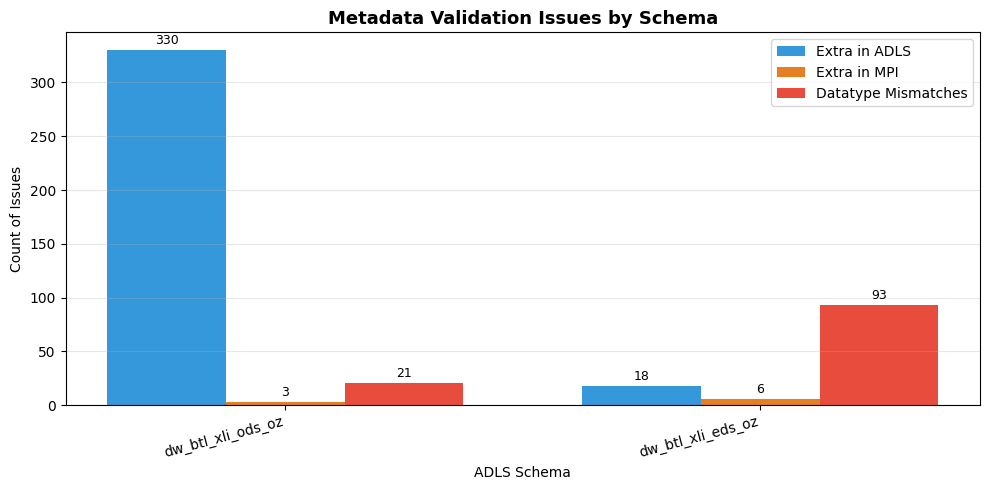

Chart saved: /Workspace/Users/manasvi.pipariya@axaxl.com/WS4_validation/validation_outputs/chart_metadata_issues_20260930_200812.png


In [0]:
# ============================================================
# Visualization: Metadata Validation Summary
# ============================================================
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np

if all_metadata_results:
    fig, ax = plt.subplots(figsize=(10, 5))
    
    schemas = [r['adls_schema'] for r in all_metadata_results]
    extra_adls = [r['extra_in_adls'] for r in all_metadata_results]
    extra_mpi = [r['extra_in_mpi'] for r in all_metadata_results]
    dtype_mm = [r['datatype_mismatches'] for r in all_metadata_results]
    
    x = np.arange(len(schemas))
    width = 0.25
    
    ax.bar(x - width, extra_adls, width, label='Extra in ADLS', color='#3498db')
    ax.bar(x, extra_mpi, width, label='Extra in MPI', color='#e67e22')
    ax.bar(x + width, dtype_mm, width, label='Datatype Mismatches', color='#e74c3c')
    
    ax.set_xlabel('ADLS Schema')
    ax.set_ylabel('Count of Issues')
    ax.set_title('Metadata Validation Issues by Schema', fontsize=13, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(schemas, rotation=15, ha='right')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for bars in ax.containers:
        ax.bar_label(bars, padding=2, fontsize=9)
    
    plt.tight_layout()
    chart3_path = os.path.join(OUTPUT_DIR, f"chart_metadata_issues_{run_timestamp}.png")
    plt.savefig(chart3_path, dpi=150, bbox_inches='tight')
    display(plt.gcf())
    plt.close()
    print(f"Chart saved: {chart3_path}")
else:
    print("No metadata results to visualize.")

In [0]:
# ============================================================
# Final Excel Report with Multiple Sheets & Embedded Charts
# ============================================================
%pip install openpyxl xlsxwriter -q

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
# ============================================================
# Build Excel report with all validation results and charts
# ============================================================
import xlsxwriter
import os

excel_path = os.path.join(OUTPUT_DIR, f"ADLS_MPI_Validation_Report_{run_timestamp}.xlsx")

# Convert Spark DataFrames to pandas
comp_pd = comparison_df.toPandas()
adls_pd = adls_counts_df.orderBy("adls_schema", "table_name").toPandas()
mpi_pd = mpi_counts_df.orderBy("mpi_database", "table_name").toPandas()

# Create workbook
workbook = xlsxwriter.Workbook(excel_path, {'nan_inf_to_errors': True})

# --- Formats ---
header_fmt = workbook.add_format({
    'bold': True, 'bg_color': '#1F4E79', 'font_color': 'white',
    'border': 1, 'text_wrap': True, 'valign': 'vcenter', 'font_size': 11
})
match_fmt = workbook.add_format({'bg_color': '#C6EFCE', 'font_color': '#006100', 'border': 1})
mismatch_fmt = workbook.add_format({'bg_color': '#FFC7CE', 'font_color': '#9C0006', 'border': 1})
error_fmt = workbook.add_format({'bg_color': '#FFEB9C', 'font_color': '#9C6500', 'border': 1})
cell_fmt = workbook.add_format({'border': 1, 'font_size': 10})
number_fmt = workbook.add_format({'border': 1, 'font_size': 10, 'num_format': '#,##0'})
pct_fmt = workbook.add_format({'border': 1, 'font_size': 10, 'num_format': '0.00"%"'})
title_fmt = workbook.add_format({'bold': True, 'font_size': 16, 'font_color': '#1F4E79'})
subtitle_fmt = workbook.add_format({'bold': True, 'font_size': 12, 'font_color': '#2E75B6'})

# ============================================================
# Sheet 1: Executive Summary
# ============================================================
ws_summary = workbook.add_worksheet('Executive Summary')
ws_summary.set_column('A:A', 35)
ws_summary.set_column('B:B', 20)

ws_summary.write('A1', 'ADLS vs MPI Validation Report', title_fmt)
ws_summary.write('A2', f'Generated: {run_timestamp}', subtitle_fmt)

row = 4
ws_summary.write(row, 0, 'Metric', header_fmt)
ws_summary.write(row, 1, 'Value', header_fmt)

total_tables = len(comp_pd)
matched_count = len(comp_pd[comp_pd['match_status'] == 'MATCHED'])
mismatched_count = len(comp_pd[comp_pd['match_status'] == 'MISMATCHED'])
error_count = total_tables - matched_count - mismatched_count
match_rate = (matched_count / total_tables * 100) if total_tables > 0 else 0

summary_data = [
    ('Total Tables Validated', total_tables),
    ('Count Matched', matched_count),
    ('Count Mismatched', mismatched_count),
    ('Errors / Not Found', error_count),
    ('Match Rate (%)', f'{match_rate:.1f}%'),
    ('', ''),
    ('Schemas Validated', ', '.join(SCHEMA_MAPPING.keys())),
    ('ADLS Catalog', BTL_CATALOG),
]

for i, (metric, value) in enumerate(summary_data):
    ws_summary.write(row + 1 + i, 0, metric, cell_fmt)
    ws_summary.write(row + 1 + i, 1, str(value), cell_fmt)

# Summary per schema
row = row + len(summary_data) + 3
ws_summary.write(row, 0, 'Per-Schema Summary', subtitle_fmt)
row += 1
for h_idx, h in enumerate(['ADLS Schema', 'MPI Database', 'Tables', 'Matched', 'Mismatched', 'Errors']):
    ws_summary.write(row, h_idx, h, header_fmt)
    ws_summary.set_column(h_idx, h_idx, 22)

for adls_schema, mpi_info in SCHEMA_MAPPING.items():
    row += 1
    schema_data = comp_pd[comp_pd['adls_schema'] == adls_schema]
    ws_summary.write(row, 0, adls_schema, cell_fmt)
    ws_summary.write(row, 1, mpi_info['mpi_database'], cell_fmt)
    ws_summary.write(row, 2, len(schema_data), number_fmt)
    ws_summary.write(row, 3, len(schema_data[schema_data['match_status'] == 'MATCHED']), match_fmt)
    ws_summary.write(row, 4, len(schema_data[schema_data['match_status'] == 'MISMATCHED']), mismatch_fmt)
    ws_summary.write(row, 5, len(schema_data[~schema_data['match_status'].isin(['MATCHED', 'MISMATCHED'])]), error_fmt)

# Metadata summary
row += 3
ws_summary.write(row, 0, 'Metadata Validation Summary', subtitle_fmt)
row += 1
for h_idx, h in enumerate(['ADLS Schema', 'MPI DB', 'Extra in ADLS', 'Extra in MPI', 'Type Mismatches']):
    ws_summary.write(row, h_idx, h, header_fmt)

for r in all_metadata_results:
    row += 1
    ws_summary.write(row, 0, r['adls_schema'], cell_fmt)
    ws_summary.write(row, 1, r['mpi_database'], cell_fmt)
    ws_summary.write(row, 2, r['extra_in_adls'], number_fmt)
    ws_summary.write(row, 3, r['extra_in_mpi'], number_fmt)
    ws_summary.write(row, 4, r['datatype_mismatches'], number_fmt)

# ============================================================
# Sheet 2: Count Comparison Detail
# ============================================================
ws_count = workbook.add_worksheet('Count Comparison')
count_cols = ['adls_schema', 'adls_table_name', 'adls_count', 'mpi_database', 'mpi_table_name', 'mpi_count', 'count_difference', 'pct_difference', 'match_status']

for c_idx, c_name in enumerate(count_cols):
    ws_count.write(0, c_idx, c_name, header_fmt)
    ws_count.set_column(c_idx, c_idx, 22)

for r_idx, (_, row_data) in enumerate(comp_pd[count_cols].iterrows()):
    for c_idx, val in enumerate(row_data):
        fmt = cell_fmt
        if c_idx in (2, 5, 6):
            fmt = number_fmt
        if c_idx == len(count_cols) - 1:  # match_status column
            if val == 'MATCHED':
                fmt = match_fmt
            elif val == 'MISMATCHED':
                fmt = mismatch_fmt
            else:
                fmt = error_fmt
        ws_count.write(r_idx + 1, c_idx, val if val is not None else '', fmt)

# ============================================================
# Sheet 3: ADLS Counts
# ============================================================
ws_adls = workbook.add_worksheet('ADLS Counts')
for c_idx, c_name in enumerate(adls_pd.columns):
    ws_adls.write(0, c_idx, c_name, header_fmt)
    ws_adls.set_column(c_idx, c_idx, 20)
for r_idx, (_, row_data) in enumerate(adls_pd.iterrows()):
    for c_idx, val in enumerate(row_data):
        ws_adls.write(r_idx + 1, c_idx, val if val is not None else '', cell_fmt)

# ============================================================
# Sheet 4: MPI Counts
# ============================================================
ws_mpi = workbook.add_worksheet('MPI Counts')
for c_idx, c_name in enumerate(mpi_pd.columns):
    ws_mpi.write(0, c_idx, c_name, header_fmt)
    ws_mpi.set_column(c_idx, c_idx, 20)
for r_idx, (_, row_data) in enumerate(mpi_pd.iterrows()):
    for c_idx, val in enumerate(row_data):
        ws_mpi.write(r_idx + 1, c_idx, val if val is not None else '', cell_fmt)

# ============================================================
# Sheet 5: Excluded Tables (ADLS-only, not found in MPI)
# ============================================================
try:
    not_found_pd = not_found_in_mpi.select("adls_schema", "adls_table_name").toPandas()
except Exception:
    not_found_pd = pd.DataFrame(columns=["adls_schema", "adls_table_name"])

ws_excluded = workbook.add_worksheet('Excluded Tables')
ws_excluded.write('A1', f'Tables in ADLS but NOT in MPI ({len(not_found_pd)} tables)', subtitle_fmt)
for c_idx, c_name in enumerate(['ADLS Schema', 'Table Name']):
    ws_excluded.write(1, c_idx, c_name, header_fmt)
    ws_excluded.set_column(c_idx, c_idx, 40)
for r_idx, (_, row_data) in enumerate(not_found_pd.iterrows()):
    for c_idx, val in enumerate(row_data):
        ws_excluded.write(r_idx + 2, c_idx, val if val is not None else '', cell_fmt)

# ============================================================
# Sheet 6: Charts
# ============================================================
ws_charts = workbook.add_worksheet('Charts')

# --- Pie chart data (write hidden data for chart) ---
ws_chart_data = workbook.add_worksheet('_chart_data')
ws_chart_data.hide()

status_counts = comp_pd['match_status'].value_counts()
for i, (status, cnt) in enumerate(status_counts.items()):
    ws_chart_data.write(i, 0, status)
    ws_chart_data.write(i, 1, cnt)

# Pie chart: overall validation status
pie_chart = workbook.add_chart({'type': 'pie'})
pie_chart.add_series({
    'name': 'Validation Status',
    'categories': ['_chart_data', 0, 0, len(status_counts)-1, 0],
    'values': ['_chart_data', 0, 1, len(status_counts)-1, 1],
    'points': [
        {'fill': {'color': '#2ecc71'}} if s == 'MATCHED' else
        {'fill': {'color': '#e74c3c'}} if s == 'MISMATCHED' else
        {'fill': {'color': '#f39c12'}}
        for s in status_counts.index
    ],
    'data_labels': {'percentage': True, 'category': True},
})
pie_chart.set_title({'name': 'Overall Count Validation Status'})
pie_chart.set_size({'width': 500, 'height': 350})
ws_charts.insert_chart('A1', pie_chart)

# Bar chart: match status by schema
schema_status_data = comp_pd.groupby(['adls_schema', 'match_status']).size().unstack(fill_value=0)
start_row = len(status_counts) + 2

# Write schema bar chart data
ws_chart_data.write(start_row, 0, 'Schema')
for j, col_name in enumerate(schema_status_data.columns):
    ws_chart_data.write(start_row, j+1, col_name)

for i, (schema, row_data) in enumerate(schema_status_data.iterrows()):
    ws_chart_data.write(start_row + 1 + i, 0, schema)
    for j, val in enumerate(row_data):
        ws_chart_data.write(start_row + 1 + i, j+1, int(val))

bar_chart = workbook.add_chart({'type': 'column', 'subtype': 'stacked'})
for j, col_name in enumerate(schema_status_data.columns):
    color = '#2ecc71' if col_name == 'MATCHED' else '#e74c3c' if col_name == 'MISMATCHED' else '#f39c12'
    bar_chart.add_series({
        'name': ['_chart_data', start_row, j+1],
        'categories': ['_chart_data', start_row+1, 0, start_row+len(schema_status_data), 0],
        'values': ['_chart_data', start_row+1, j+1, start_row+len(schema_status_data), j+1],
        'fill': {'color': color},
    })
bar_chart.set_title({'name': 'Validation Status by Schema'})
bar_chart.set_x_axis({'name': 'Schema'})
bar_chart.set_y_axis({'name': 'Table Count'})
bar_chart.set_size({'width': 600, 'height': 400})
ws_charts.insert_chart('A20', bar_chart)

# Bar chart: Metadata issues
if all_metadata_results:
    meta_start = start_row + len(schema_status_data) + 3
    ws_chart_data.write(meta_start, 0, 'Schema')
    ws_chart_data.write(meta_start, 1, 'Extra in ADLS')
    ws_chart_data.write(meta_start, 2, 'Extra in MPI')
    ws_chart_data.write(meta_start, 3, 'Type Mismatches')
    
    for i, r in enumerate(all_metadata_results):
        ws_chart_data.write(meta_start + 1 + i, 0, r['adls_schema'])
        ws_chart_data.write(meta_start + 1 + i, 1, r['extra_in_adls'])
        ws_chart_data.write(meta_start + 1 + i, 2, r['extra_in_mpi'])
        ws_chart_data.write(meta_start + 1 + i, 3, r['datatype_mismatches'])
    
    meta_chart = workbook.add_chart({'type': 'column'})
    for j, name in enumerate(['Extra in ADLS', 'Extra in MPI', 'Type Mismatches']):
        colors = ['#3498db', '#e67e22', '#e74c3c']
        meta_chart.add_series({
            'name': name,
            'categories': ['_chart_data', meta_start+1, 0, meta_start+len(all_metadata_results), 0],
            'values': ['_chart_data', meta_start+1, j+1, meta_start+len(all_metadata_results), j+1],
            'fill': {'color': colors[j]},
        })
    meta_chart.set_title({'name': 'Metadata Validation Issues by Schema'})
    meta_chart.set_x_axis({'name': 'Schema'})
    meta_chart.set_y_axis({'name': 'Issue Count'})
    meta_chart.set_size({'width': 600, 'height': 400})
    ws_charts.insert_chart('A40', meta_chart)

workbook.close()
print(f"\nFinal Excel report saved to: {excel_path}")
print(f"Sheets: Executive Summary, Count Comparison, ADLS Counts, MPI Counts, Charts")


Final Excel report saved to: /Workspace/Users/manasvi.pipariya@axaxl.com/WS4_validation/validation_outputs/ADLS_MPI_Validation_Report_20260930_200812.xlsx
Sheets: Executive Summary, Count Comparison, ADLS Counts, MPI Counts, Charts


In [0]:
# ============================================================
# Final Summary of All Outputs
# ============================================================
print("=" * 80)
print("VALIDATION COMPLETE")
print("=" * 80)
print(f"\nRun Timestamp: {run_timestamp}")
print(f"Output Directory: {OUTPUT_DIR}")
print(f"\nGenerated Files:")
print(f"  1. ADLS Counts CSV     : adls_counts_{run_timestamp}.csv")
print(f"  2. MPI Counts CSV      : mpi_counts_{run_timestamp}.csv")
print(f"  3. Comparison CSV      : count_comparison_{run_timestamp}.csv")
print(f"  4. Excel Report        : ADLS_MPI_Validation_Report_{run_timestamp}.xlsx")
print(f"  5. Chart (Status)      : chart_count_status_{run_timestamp}.png")
print(f"  6. Chart (Mismatches)  : chart_mismatch_detail_{run_timestamp}.png")
print(f"  7. Chart (Metadata)    : chart_metadata_issues_{run_timestamp}.png")
print(f"\nCount Validation:")
print(f"  Total Tables : {total_tables}")
print(f"  Matched      : {matched_count}")
print(f"  Mismatched   : {mismatched_count}")
print(f"  Errors       : {error_count}")
print(f"  Match Rate   : {match_rate:.1f}%")
try:
    _exc = not_found_in_mpi.count()
    print(f"  Excluded (ADLS-only, not in MPI): {_exc}")
except Exception:
    pass
print(f"\nMetadata Validation:")
for r in all_metadata_results:
    print(f"  {r['adls_schema']}: Extra ADLS={r['extra_in_adls']}, Extra MPI={r['extra_in_mpi']}, Type Mismatches={r['datatype_mismatches']}")
print("\n" + "=" * 80)

VALIDATION COMPLETE

Run Timestamp: 20260930_200812
Output Directory: /Workspace/Users/manasvi.pipariya@axaxl.com/WS4_validation/validation_outputs

Generated Files:
  1. ADLS Counts CSV     : adls_counts_20260930_200812.csv
  2. MPI Counts CSV      : mpi_counts_20260930_200812.csv
  3. Comparison CSV      : count_comparison_20260930_200812.csv
  4. Excel Report        : ADLS_MPI_Validation_Report_20260930_200812.xlsx
  5. Chart (Status)      : chart_count_status_20260930_200812.png
  6. Chart (Mismatches)  : chart_mismatch_detail_20260930_200812.png
  7. Chart (Metadata)    : chart_metadata_issues_20260930_200812.png

Count Validation:
  Total Tables : 246
  Matched      : 240
  Mismatched   : 5
  Errors       : 1
  Match Rate   : 97.6%
  Excluded (ADLS-only, not in MPI): 10

Metadata Validation:
  dw_btl_xli_ods_oz: Extra ADLS=330, Extra MPI=3, Type Mismatches=21
  dw_btl_xli_eds_oz: Extra ADLS=18, Extra MPI=6, Type Mismatches=93



In [0]:
# ============================================================
# Tables present in ADLS but NOT found in MPI
# ============================================================
from pyspark.sql.functions import col

not_found_df = mpi_counts_df.filter(col("mpi_status") == "TABLE_NOT_FOUND_IN_MPI") \
    .select("mpi_database", "mpi_schema", "table_name") \
    .orderBy("mpi_database", "table_name")

not_found_count = not_found_df.count()
print(f"Total tables NOT FOUND in MPI: {not_found_count}")
print("=" * 60)

if not_found_count > 0:
    not_found_rows = not_found_df.collect()
    for i, row in enumerate(not_found_rows, 1):
        print(f"  {i}. {row['mpi_database']}.{row['mpi_schema']}.{row['table_name']}")
    display(not_found_df)
else:
    print("All ADLS tables were found in MPI.")

Total tables NOT FOUND in MPI: 10
  1. eds.dbo.lk_narratives
  2. eds.dbo.lk_policysectiondetail
  3. eds.dbo.lk_ribordereau
  4. ods3.dbo.allocationhistory_inc
  5. ods3.dbo.corpclaimpayments
  6. ods3.dbo.corpreservedeltaoutwards
  7. ods3.dbo.corpreservedeltas
  8. ods3.dbo.inwardscoinsurancegroup
  9. ods3.dbo.lm45
  10. ods3.dbo.lm45_claim_policy_inwards_outwards


mpi_database,mpi_schema,table_name
eds,dbo,lk_narratives
eds,dbo,lk_policysectiondetail
eds,dbo,lk_ribordereau
ods3,dbo,allocationhistory_inc
ods3,dbo,corpclaimpayments
ods3,dbo,corpreservedeltaoutwards
ods3,dbo,corpreservedeltas
ods3,dbo,inwardscoinsurancegroup
ods3,dbo,lm45
ods3,dbo,lm45_claim_policy_inwards_outwards
